> **Versão pública (2026).** Notebook original, executado no Google Colab em outubro de 2022, com os dados numa pasta do Google Drive (`<PASTA_DO_PROJETO>`). As saídas são as originais. Veja o [README](../README.md).

In [1]:
!pip install --upgrade pandas

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [146]:
import os
import shutil
from google.colab import drive

import pandas as pd
import numpy as np

import random
from IPython.display import clear_output

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

from matplotlib.animation import FuncAnimation, PillowWriter

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


# Lê Dados das Votações por Seção Eleitoral

In [4]:
#Arquivos baixados do site do TSE
#https://dadosabertos.tse.jus.br/dataset/resultados-2022
#https://dadosabertos.tse.jus.br/dataset/resultados-2022-boletim-de-urna

#Outra Opção de Fonte:
#https://basedosdados.org/dataset/br-tse-eleicoes?bdm_table=resultados_candidato_secao

path_dados = '<PASTA_DO_PROJETO>/dados_votacao'
lista_arquivos = ['detalhe_votacao_secao_2022.zip', 'votacao_secao_2022_BR.zip']
print(lista_arquivos)

path_dados_boletim = '<PASTA_DO_PROJETO>/dados_boletim_urna'
lista_arquivos_boletim = os.listdir(path_dados_boletim)
print(len(lista_arquivos_boletim))

['detalhe_votacao_secao_2022.zip', 'votacao_secao_2022_BR.zip']
28


In [5]:
#Descompacta os arquivos
for arq in lista_arquivos:
    pasta = arq.split('.')[0]
    os.system(f'unzip {path_dados}/{arq} -d {pasta}')

In [6]:
def leitura_dados(pasta, arq_csv):
    return pd.read_csv(f'{pasta}/{arq_csv}', sep = ';', engine = 'c', encoding = 'latin-1')

arq = 'detalhe_votacao_secao_2022.zip'
pasta = arq.split('.')[0]
arq_csv = [f for f in os.listdir(pasta) if f.find('.csv') != -1 and f.find('_BRASIL') != -1][0]
df_desc_inp = leitura_dados(pasta, arq_csv)

arq = 'votacao_secao_2022_BR.zip'
pasta = arq.split('.')[0]
arq_csv = [f for f in os.listdir(pasta) if f.find('.csv') != -1][0]
df_inp = leitura_dados(pasta, arq_csv)

In [7]:
def trata_detalhe(df_desc_inp):
    df_desc = df_desc_inp[df_desc_inp['DS_CARGO'] == 'PRESIDENTE']
    cols_id = ['SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO']
    cols_info = ['QT_APTOS', 'QT_COMPARECIMENTO', 'QT_ABSTENCOES', 'QT_VOTOS_NOMINAIS', 'QT_VOTOS_BRANCOS', 'QT_VOTOS_NULOS']
    df_desc = df_desc[np.append(cols_id, cols_info)].reset_index(drop = True)
    return df_desc.reset_index().rename({'index': 'ID_URNA'}, axis = 1).copy()

def trata_votacao(df_inp, df_desc):
    df = df_inp[df_inp['DS_CARGO'] == 'PRESIDENTE']
    cols_id = ['SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'NM_VOTAVEL']
    cols_info = ['QT_VOTOS']
    df = df[np.append(cols_id, cols_info)].reset_index(drop = True).copy()
    cols_urna = ['ID_URNA', 'SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO']
    return pd.merge(df, df_desc[cols_urna], how = 'left', on = ['SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'])

In [8]:
df_desc = trata_detalhe(df_desc_inp)
df_desc.sample(n = 5).T

,370423,253651,183455,35546,259213
ID_URNA,370423,253651,183455,35546,259213
SG_UF,PE,MG,RJ,SP,PE
NM_MUNICIPIO,NAZARÉ DA MATA,POÇOS DE CALDAS,RIO DE JANEIRO,SANTA ADÉLIA,RECIFE
NR_ZONA,23,222,176,111,9
NR_SECAO,100,71,153,19,330
QT_APTOS,313,306,492,275,394
QT_COMPARECIMENTO,276,216,404,183,342
QT_ABSTENCOES,37,90,88,92,52
QT_VOTOS_NOMINAIS,263,206,390,172,327
QT_VOTOS_BRANCOS,3,4,5,6,4


In [9]:
df = trata_votacao(df_inp, df_desc)
df.sample(n = 5).T

,3214965,1392095,2257900,3027500,584907
SG_UF,PE,MA,SP,RJ,SP
NM_MUNICIPIO,JABOATÃO DOS GUARARAPES,ESTREITO,SÃO PAULO,NITERÓI,LIMEIRA
NR_ZONA,118,82,20,144,399
NR_SECAO,286,51,442,162,107
NM_VOTAVEL,JAIR MESSIAS BOLSONARO,LUIZ INÁCIO LULA DA SILVA,CIRO FERREIRA GOMES,SORAYA VIEIRA THRONICKE,KELMON LUIS DA SILVA SOUZA
QT_VOTOS,135,119,9,2,1
ID_URNA,287261,231443,221935,207243,247866


In [10]:
#Descompacta os arquivos dos boletins
for arq in lista_arquivos_boletim:
    pasta = arq.split('.')[0]
    os.system(f'unzip {path_dados_boletim}/{arq} -d {pasta}')

In [11]:
def leitura_dados_boletim(pasta, arq_csv):
    df_temp = pd.read_csv(f'{pasta}/{arq_csv}', usecols = ['SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'DT_BU_RECEBIDO'],
                       sep = ';', engine = 'c', encoding = 'latin-1')
    df_temp = df_temp.drop_duplicates()
    return df_temp

lista_df_boletim = []
for arq in lista_arquivos_boletim:
    clear_output(wait = True)
    print(arq)

    pasta = arq.split('.')[0]
    arq_csv = [f for f in os.listdir(pasta) if f.find('.csv') != -1][0]
    lista_df_boletim.append(leitura_dados_boletim(pasta, arq_csv))

df_bol = pd.concat(lista_df_boletim)

bweb_1t_ZZ_051020221321.zip


In [16]:
df_desc_compl = pd.merge(df_desc, df_bol, how = 'left', on = ['SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'])

#df_desc_compl['DT_BU_RECEBIDO'] = pd.to_datetime(df_desc_compl['DT_BU_RECEBIDO'], format = '%d/%m/%Y %H:%M:%S')
df_desc_compl['DT_BU_RECEBIDO'] = pd.to_datetime(df_desc_compl['DT_BU_RECEBIDO'].str[:-3], format = '%d/%m/%Y %H:%M')

#Preenche data que ficaram nulas (usa a maior data de cada estado)
for uf in df_desc_compl['SG_UF'].unique():
    mask_sem_dt = (df_desc_compl['SG_UF'] == uf) & (df_desc_compl['DT_BU_RECEBIDO'].isna())
    dt_max = df_desc_compl.loc[df_desc_compl['SG_UF'] == uf, 'DT_BU_RECEBIDO'].max()
    df_desc_compl.loc[mask_sem_dt, 'DT_BU_RECEBIDO'] = dt_max

dt_max = df_desc_compl.loc[df_desc_compl['DT_BU_RECEBIDO'] < '2022-10-03', 'DT_BU_RECEBIDO'].max()
df_desc_compl.loc[df_desc_compl['DT_BU_RECEBIDO'] >= '2022-10-03', 'DT_BU_RECEBIDO'] = dt_max

# Resultados da Eleição

In [17]:
df_res = df[['NM_VOTAVEL', 'QT_VOTOS']].groupby('NM_VOTAVEL').sum().sort_values('QT_VOTOS', ascending = False)
df_res['PERC_VOTOS'] = df_res['QT_VOTOS']*100/df_res['QT_VOTOS'].sum()
df_res['PERC_VOTOS_VALIDOS'] = df_res['QT_VOTOS']*100/df_res.loc[~df_res.index.isin(['VOTO NULO', 'VOTO BRANCO']), 'QT_VOTOS'].sum()
display(df_res)

,QT_VOTOS,PERC_VOTOS,PERC_VOTOS_VALIDOS
NM_VOTAVEL,,,
LUIZ INÁCIO LULA DA SILVA,57259504,46.295606,48.430720
JAIR MESSIAS BOLSONARO,51072345,41.293148,43.197553
SIMONE NASSAR TEBET,4915423,3.974231,4.157519
CIRO FERREIRA GOMES,3599287,2.910105,3.044317
VOTO NULO,3487874,2.820025,2.950082
VOTO BRANCO,1964779,1.588568,1.661832
SORAYA VIEIRA THRONICKE,600955,0.485886,0.508294
LUIZ FELIPE CHAVES D AVILA,559708,0.452537,0.473407
KELMON LUIS DA SILVA SOUZA,81129,0.065595,0.068620


# Evolução Temporal da Apuração

In [18]:
df_temporal = pd.merge(df[['ID_URNA', 'NM_VOTAVEL', 'QT_VOTOS']], df_desc_compl[['ID_URNA', 'DT_BU_RECEBIDO']], 
                       how = 'left', on = 'ID_URNA').drop('ID_URNA', axis = 1).sort_values('DT_BU_RECEBIDO')
df_res_temporal = df_temporal.groupby(['DT_BU_RECEBIDO', 'NM_VOTAVEL']).sum()

df_res_temporal = df_res_temporal.reset_index().pivot(index = 'DT_BU_RECEBIDO', columns = 'NM_VOTAVEL', values = 'QT_VOTOS')
df_res_temporal = df_res_temporal.sort_index().fillna(0)

for c in df_res_temporal.columns:
    df_res_temporal[c] = df_res_temporal[c].cumsum()

total = df_res_temporal.sum(axis = 1)
for c in df_res_temporal.columns:
    df_res_temporal[c] = df_res_temporal[c]/total

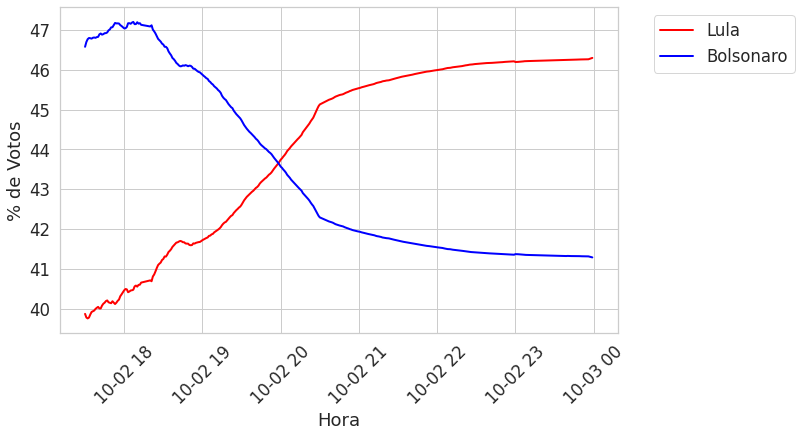

In [21]:
df_plot = df_res_temporal[df_res_temporal.index >= '2022-10-02 17:30:00']

paleta_cores = sns.color_palette("colorblind")
dict_cores = {'LUIZ INÁCIO LULA DA SILVA': 'red',
              'JAIR MESSIAS BOLSONARO': 'blue'}
dict_label = {'LUIZ INÁCIO LULA DA SILVA': 'Lula',
              'JAIR MESSIAS BOLSONARO': 'Bolsonaro'}

with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (10, 6))
    for candidato in ['LUIZ INÁCIO LULA DA SILVA', 'JAIR MESSIAS BOLSONARO']:
        ax.plot(df_plot.index, df_plot[candidato]*100, lw = 2,
                color = dict_cores[candidato], label = dict_label[candidato])
    #ax.set_ylim(bottom = 0, top = 100)
    ax.set_xlabel('Hora')
    ax.set_ylabel('% de Votos')
    ax.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
    plt.xticks(rotation = 45)
    plt.show()

# Resultado Estimado

In [22]:
df_uf_aptos = df_desc[['SG_UF', 'QT_APTOS']].groupby('SG_UF').sum()

In [43]:
df_temporal_est = pd.merge(df[['ID_URNA', 'SG_UF', 'NM_VOTAVEL', 'QT_VOTOS']], 
                           df_desc_compl[['ID_URNA', 'DT_BU_RECEBIDO']], 
                           how = 'left', on = 'ID_URNA').drop('ID_URNA', axis = 1).sort_values('DT_BU_RECEBIDO')

In [45]:
def calcula_votos_estimados(df_temporal_est, df_uf_aptos, dt):
    df_aux = df_temporal_est[df_temporal_est['DT_BU_RECEBIDO'] <= dt]
    df_temp = df_aux[['SG_UF', 'NM_VOTAVEL', 'QT_VOTOS']].groupby(['SG_UF', 'NM_VOTAVEL']).sum().reset_index()

    df_uf_votos = df_aux[['SG_UF', 'QT_VOTOS']].groupby('SG_UF').sum()

    df_uf = pd.concat([df_uf_aptos, df_uf_votos], axis = 1).fillna(0)
    df_uf['Fator_Estimativa'] = (df_uf['QT_APTOS']/df_uf['QT_VOTOS'])
    df_uf.loc[df_uf['QT_VOTOS'] == 0, 'Fator_Estimativa'] = 1
    df_uf = df_uf.drop(['QT_APTOS', 'QT_VOTOS'], axis = 1).reset_index()

    df_temp = pd.merge(df_temp, df_uf, how = 'left', on = 'SG_UF')
    df_temp['QT_VOTOS_ESTIMADO'] = df_temp['QT_VOTOS']*df_temp['Fator_Estimativa']
    df_temp = df_temp.drop(['Fator_Estimativa', 'SG_UF'], axis = 1)

    df_temp = df_temp.groupby('NM_VOTAVEL').sum().reset_index()
    df_temp['DT_BU_RECEBIDO'] = dt

    return df_temp

vetor_datas = np.sort(df_desc_compl['DT_BU_RECEBIDO'].unique())
lista_df_aux = []
for dt in vetor_datas:
    clear_output(wait = True)
    print(dt)
    lista_df_aux.append(calcula_votos_estimados(df_temporal_est, df_uf_aptos, dt))

2022-10-02T23:59:00.000000000


In [30]:
#Resultado Ocorrido

df_res_temporal = pd.concat(lista_df_aux).groupby(['DT_BU_RECEBIDO', 'NM_VOTAVEL']).sum()
df_res_temporal = df_res_temporal.drop('QT_VOTOS_ESTIMADO', axis = 1)

df_res_temporal = df_res_temporal.reset_index().pivot(index = 'DT_BU_RECEBIDO', 
                                                      columns = 'NM_VOTAVEL', 
                                                      values = 'QT_VOTOS')
df_res_temporal = df_res_temporal.sort_index().fillna(0)

total = df_res_temporal.sum(axis = 1)
for c in df_res_temporal.columns:
    df_res_temporal[c] = df_res_temporal[c]/total

#Resultado Estimado

df_res_temporal_est = pd.concat(lista_df_aux).groupby(['DT_BU_RECEBIDO', 'NM_VOTAVEL']).sum()
df_res_temporal_est['QT_VOTOS_ESTIMADO'] = df_res_temporal_est['QT_VOTOS_ESTIMADO'].astype(int)
df_res_temporal_est = df_res_temporal_est.drop('QT_VOTOS', axis = 1)

df_res_temporal_est = df_res_temporal_est.reset_index().pivot(index = 'DT_BU_RECEBIDO', 
                                                              columns = 'NM_VOTAVEL', 
                                                              values = 'QT_VOTOS_ESTIMADO')
df_res_temporal_est = df_res_temporal_est.sort_index().fillna(0)


total = df_res_temporal_est.sum(axis = 1)
for c in df_res_temporal_est.columns:
    df_res_temporal_est[c] = df_res_temporal_est[c]/total

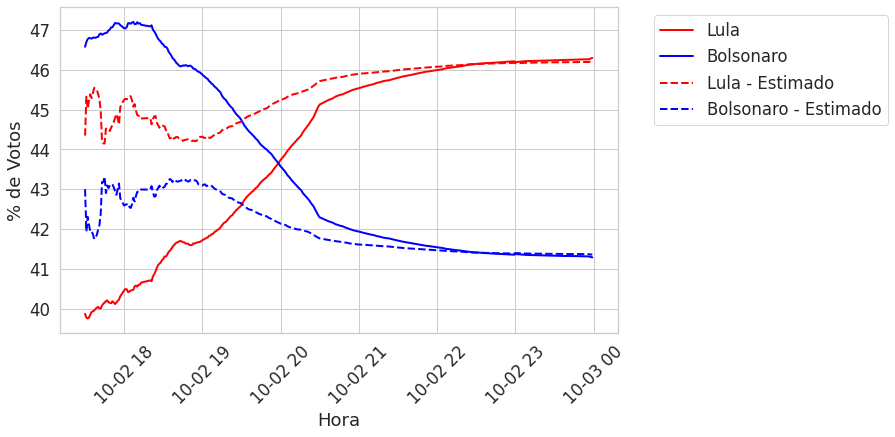

In [78]:
df_plot = df_res_temporal[df_res_temporal.index >= '2022-10-02 17:30:00']
df_plot_est = df_res_temporal_est[df_res_temporal_est.index >= '2022-10-02 17:30:00']

paleta_cores = sns.color_palette("colorblind")
dict_cores = {'LUIZ INÁCIO LULA DA SILVA': 'red',
              'JAIR MESSIAS BOLSONARO': 'blue'}
dict_label = {'LUIZ INÁCIO LULA DA SILVA': 'Lula',
              'JAIR MESSIAS BOLSONARO': 'Bolsonaro'}

with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (10, 6))
    for candidato in ['LUIZ INÁCIO LULA DA SILVA', 'JAIR MESSIAS BOLSONARO']:
        ax.plot(df_plot.index, df_plot[candidato]*100, lw = 2,
                color = dict_cores[candidato], label = dict_label[candidato])
    for candidato in ['LUIZ INÁCIO LULA DA SILVA', 'JAIR MESSIAS BOLSONARO']:
        ax.plot(df_plot_est.index, df_plot_est[candidato]*100, '--', lw = 2,
                color = dict_cores[candidato], label = dict_label[candidato] + ' - Estimado')
    #ax.set_ylim(bottom = 0, top = 100)
    ax.set_xlabel('Hora')
    ax.set_ylabel('% de Votos')
    ax.legend(bbox_to_anchor = (1.05, 1), loc = 'upper left')
    ax.tick_params(axis = 'x', rotation = 45)
    plt.show()

# Processamento para Gráfico Animado

In [38]:
df_uf_aptos = df_desc[['SG_UF', 'QT_APTOS']].groupby('SG_UF').agg(['sum', 'count'])
df_uf_aptos.columns = ['QT_APTOS', 'QT_URNAS']

In [46]:
df_temporal_est = pd.merge(df[['ID_URNA', 'SG_UF', 'NM_VOTAVEL', 'QT_VOTOS']], 
                           df_desc_compl[['ID_URNA', 'DT_BU_RECEBIDO']], 
                           how = 'left', on = 'ID_URNA').sort_values('DT_BU_RECEBIDO')

In [66]:
def calcula_dados_animacao(df_temporal_est, df_uf_aptos, dt):
    df_aux = df_temporal_est[df_temporal_est['DT_BU_RECEBIDO'] <= dt]

    ###############
    df_temp = df_aux[['SG_UF', 'NM_VOTAVEL', 'QT_VOTOS']].groupby(['SG_UF', 'NM_VOTAVEL']).sum().reset_index()

    df_uf_votos = df_aux[['SG_UF', 'QT_VOTOS']].groupby('SG_UF').sum()
    df_uf_votos.columns = ['QT_VOTOS_UF']
    df_uf_votos = df_uf_votos.reset_index()

    df_temp = pd.merge(df_temp, df_uf_votos, how = 'left', on = 'SG_UF')
    df_temp['PC_VOTOS'] = df_temp['QT_VOTOS']*100/df_temp['QT_VOTOS_UF']
    df_temp = df_temp.drop(['QT_VOTOS', 'QT_VOTOS_UF'], axis = 1)

    ###############
    df_temp_urnas = df_aux[['SG_UF', 'ID_URNA']].drop_duplicates().groupby(['SG_UF']).count()
    df_temp_urnas.columns = ['QT_URNAS_APURADAS']
    df_temp_urnas = df_temp_urnas.reset_index()

    df_temp_urnas = pd.merge(df_temp_urnas, df_uf_aptos.drop('QT_APTOS', axis = 1), how = 'left', on = 'SG_UF')
    df_temp_urnas['PC_URNAS_APURADAS'] = df_temp_urnas['QT_URNAS_APURADAS']*100/df_temp_urnas['QT_URNAS']
    df_temp_urnas = df_temp_urnas.drop(['QT_URNAS_APURADAS', 'QT_URNAS'], axis = 1)

    return (df_temp, df_temp_urnas)

vetor_datas = np.sort(df_desc_compl['DT_BU_RECEBIDO'].unique())
dict_animacao = {}
for dt in vetor_datas:
    clear_output(wait = True)
    print(dt)
    dict_animacao[dt] = calcula_dados_animacao(df_temporal_est, df_uf_aptos, dt)

2022-10-02T23:59:00.000000000


### Layout do Gráfico dos Frame

In [166]:
dt = vetor_datas[200]
dt

numpy.datetime64('2022-10-02T18:53:00.000000000')

In [167]:
df_plot = df_res_temporal[df_res_temporal.index >= '2022-10-02 17:30:00']
df_plot_est = df_res_temporal_est[df_res_temporal_est.index >= '2022-10-02 17:30:00']

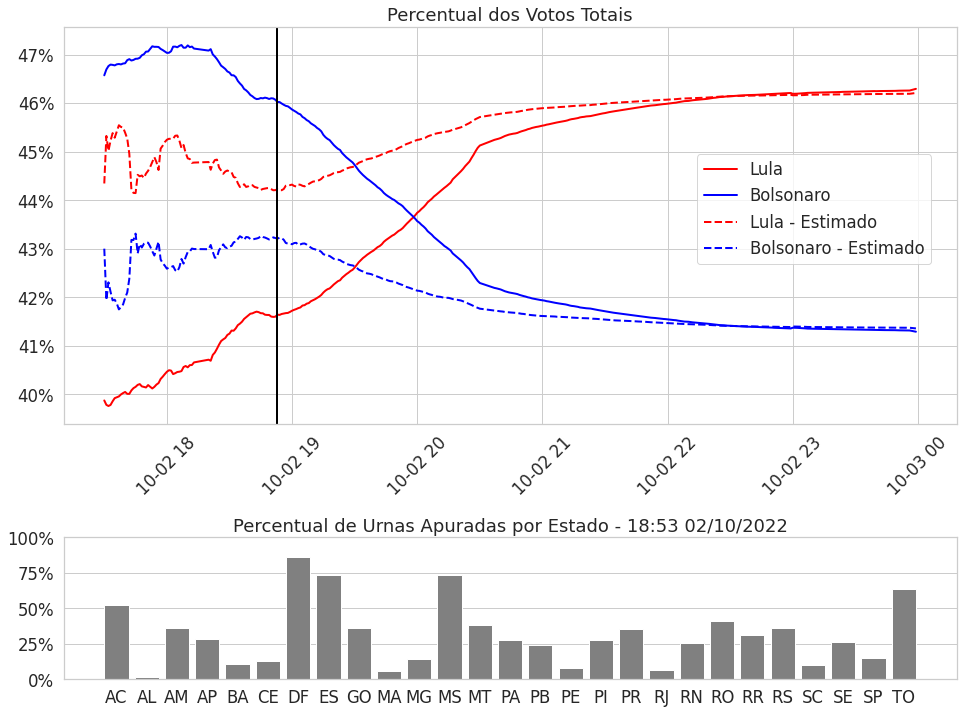

In [172]:
paleta_cores = sns.color_palette("colorblind")
dict_cores = {'LUIZ INÁCIO LULA DA SILVA': 'red',
              'JAIR MESSIAS BOLSONARO': 'blue'}
dict_label = {'LUIZ INÁCIO LULA DA SILVA': 'Lula',
              'JAIR MESSIAS BOLSONARO': 'Bolsonaro'}
candidatos_plot = ['LUIZ INÁCIO LULA DA SILVA', 'JAIR MESSIAS BOLSONARO']

with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    #fig, ax = plt.subplots(1, 1, figsize = (10, 6))
    gridsize = (3, 2)
    fig = plt.figure(figsize = (16, 12))
    ax1 = plt.subplot2grid(gridsize, (0, 0), colspan = 2, rowspan = 2)
    ax2 = plt.subplot2grid(gridsize, (2, 0), colspan = 2, rowspan = 1)
    #ax2 = plt.subplot2grid(gridsize, (2, 0))
    #ax3 = plt.subplot2grid(gridsize, (2, 1))
    plt.subplots_adjust(wspace = 0.3, hspace = 0.8)

    #################

    ax = ax1
    ax.cla()

    for candidato in candidatos_plot:
        ax.plot(df_plot.index, df_plot[candidato]*100, lw = 2,
                color = dict_cores[candidato], label = dict_label[candidato])
    for candidato in candidatos_plot:
        ax.plot(df_plot_est.index, df_plot_est[candidato]*100, '--', lw = 2,
                color = dict_cores[candidato], label = dict_label[candidato] + ' - Estimado')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals = 0))
    ax.set_title('Percentual dos Votos Totais')
    ax.legend(bbox_to_anchor = (0.7, 0.7), loc = 'upper left')
    ax.tick_params(axis = 'x', rotation = 45)

    ax.axvline(dt, color = 'black', lw = 2)

    #################

    ax = ax2
    ax.cla()

    df_plot_temp = dict_animacao[dt][1]
    df_plot_temp = df_plot_temp[df_plot_temp['SG_UF'] != 'ZZ']
    ax.bar(df_plot_temp['SG_UF'], df_plot_temp['PC_URNAS_APURADAS'], color = 'grey')
    ax.set_ylim(0, 100)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals = 0))
    ax.set_title('Percentual de Urnas Apuradas por Estado - ' + pd.to_datetime(dt).strftime('%H:%M %d/%m/%Y'))
    ax.grid(axis = 'x')

    plt.show()

### Animação

In [173]:
vetor_dts_plot = np.array([v for v in vetor_datas if v >= pd.to_datetime('2022-10-02 17:30:00')])

In [174]:
df_plot = df_res_temporal[df_res_temporal.index >= '2022-10-02 17:30:00']
df_plot_est = df_res_temporal_est[df_res_temporal_est.index >= '2022-10-02 17:30:00']

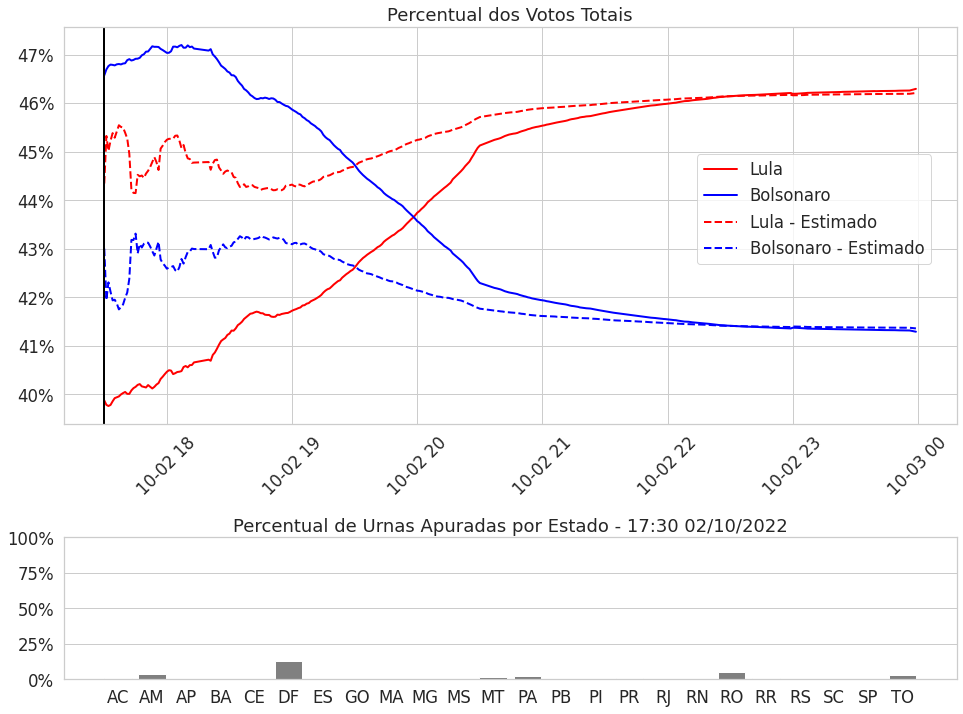

In [175]:
def update_frame(dt):
    ax = ax1
    ax.cla()

    for candidato in candidatos_plot:
        ax.plot(df_plot.index, df_plot[candidato]*100, lw = 2,
                color = dict_cores[candidato], label = dict_label[candidato])
    for candidato in candidatos_plot:
        ax.plot(df_plot_est.index, df_plot_est[candidato]*100, '--', lw = 2,
                color = dict_cores[candidato], label = dict_label[candidato] + ' - Estimado')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals = 0))
    ax.set_title('Percentual dos Votos Totais')
    ax.legend(bbox_to_anchor = (0.7, 0.7), loc = 'upper left')
    ax.tick_params(axis = 'x', rotation = 45)

    ax.axvline(dt, color = 'black', lw = 2)

    #################

    ax = ax2
    ax.cla()

    df_plot_temp = dict_animacao[dt][1]
    df_plot_temp = df_plot_temp[df_plot_temp['SG_UF'] != 'ZZ']
    ax.bar(df_plot_temp['SG_UF'], df_plot_temp['PC_URNAS_APURADAS'], color = 'grey')
    ax.set_ylim(0, 100)
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals = 0))
    ax.set_title('Percentual de Urnas Apuradas por Estado - ' + pd.to_datetime(dt).strftime('%H:%M %d/%m/%Y'))
    ax.grid(axis = 'x')

with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    gridsize = (3, 2)
    fig = plt.figure(figsize = (16, 12))
    ax1 = plt.subplot2grid(gridsize, (0, 0), colspan = 2, rowspan = 2)
    ax2 = plt.subplot2grid(gridsize, (2, 0), colspan = 2, rowspan = 1)
    plt.subplots_adjust(wspace = 0.3, hspace = 0.8)

    ani = FuncAnimation(fig, 
                        update_frame, 
                        frames = vetor_dts_plot,
                        repeat = True)
    
    ani.save("animacao.gif", dpi = 300, writer = PillowWriter(fps = 4))
    plt.show()

In [176]:
!cp animacao.gif <PASTA_DO_PROJETO>/animacao.gif